# Model Training: KNN

In [1]:
import warnings
warnings.filterwarnings("ignore")

In [2]:
from sklearn.feature_selection import VarianceThreshold
import seaborn as sns
import numpy as np
from sklearn.neighbors import NearestNeighbors
from sklearn.preprocessing import StandardScaler

One of the potential algorithms behind our recommender is KNN. The essence of the algorithm is to select the nearest, most similar observation to a given point based a defines heuristc
and a set of features. This is exactly what a recommender does.

## 1. Data Load

In [3]:
import sys
import os
import logging
from pathlib import Path
from datetime import datetime
from dotenv import load_dotenv

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

# Add project root to path for imports
project_root = Path.cwd().parent
sys.path.insert(0, str(project_root))

# Load environment and config (force refresh)
load_dotenv(project_root / '.env', override=True)
from soeSpotify import config

# Styling
sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (12, 6)
palette = sns.color_palette("viridis", as_cmap=False)

print("Setup complete.")

Setup complete.


In [4]:
print("Loading analytical datasets...")

# We use the analytics stage data as it is already cleaned and joined
df_tracks = pd.read_parquet(config.ANALYTICS_TRACKS)
df_artists = pd.read_parquet(config.ANALYTICS_ARTISTS)
df_genres = pd.read_parquet(config.ANALYTICS_GENRES)
df_features = pd.read_parquet(config.ANALYTICS_TRACK_FEATURES)

print(f"Tracks loaded:   {len(df_tracks):,}")
print(f"Artists loaded:  {len(df_artists):,}")
print(f"Genres loaded:   {len(df_genres):,}")
print(f"Features loaded: {len(df_features):,}")

Loading analytical datasets...
Tracks loaded:   101,144
Artists loaded:  56,129
Genres loaded:   87,202
Features loaded: 101,144


In [5]:
df_tracks.columns

Index(['track_id', 'track_name', 'track_popularity', 'duration_ms',
       'preview_url', 'uri', 'album_id', 'album_name', 'album_type',
       'release_date', 'artists_id', 'artist_name', 'artist_popularity',
       'artist_followers', 'genres', 'is_podcast', 'artist_primary_genre',
       'artist_secondary_genre', 'artist_primary_genre_broad',
       'artist_secondary_genre_broad', 'acousticness', 'danceability',
       'energy', 'instrumentalness', 'key', 'liveness', 'loudness', 'mode',
       'speechiness', 'tempo', 'time_signature', 'valence',
       'mean_syllables_word', 'mean_words_sentence', 'n_sentences', 'n_words',
       'sentence_similarity', 'vocabulary_wealth',
       'artist_primary_genre_broad_original', 'genre_broad_was_imputed'],
      dtype='str')

## 2. Feature Selection and Preprocessing

In [ ]:
df_tracks = df_tracks[df_tracks['is_podcast'] == 'no']

In [7]:
# output the number of observations for each genre in artist_primary_genre_broad
df_tracks.groupby('artist_primary_genre_broad').size()

artist_primary_genre_broad
blues          3133
classical     10451
electronic     3820
folk           2222
hip hop       13745
house          5333
indie          9228
jazz           3477
metal          5847
pop           17648
r&b            5005
rock           9169
world          4207
dtype: int64

<Axes: >

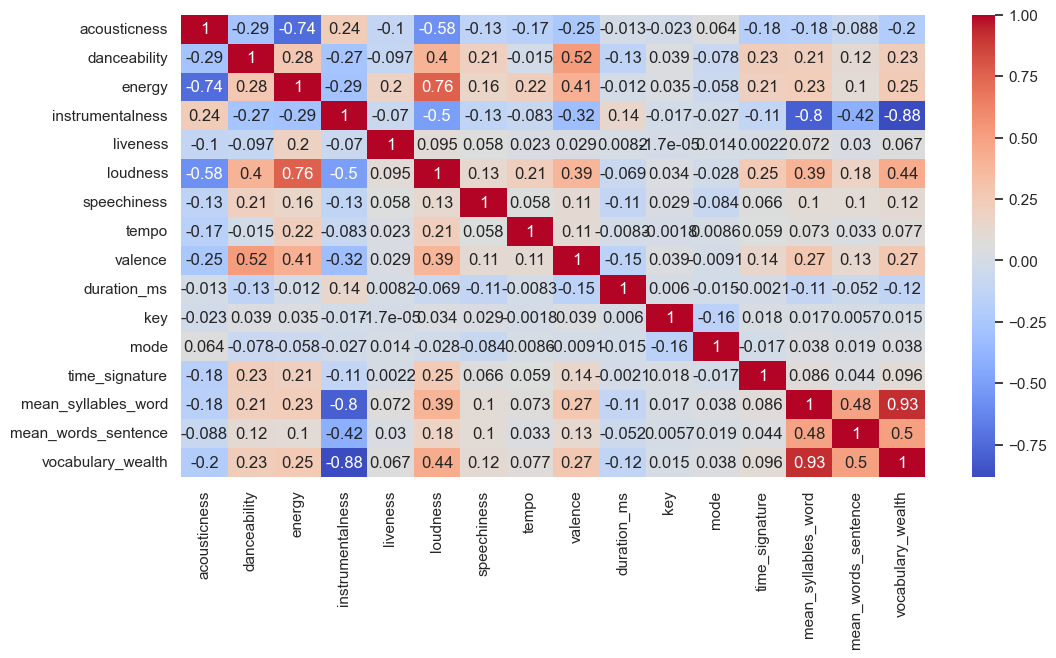

In [8]:
audio_features = ['acousticness', 'danceability', 'energy', 'instrumentalness',
                  'liveness', 'loudness', 'speechiness', 'tempo', 'valence',
                  'duration_ms', 'key', 'mode', 'time_signature',
                  'mean_syllables_word', 'mean_words_sentence', 'vocabulary_wealth']

corr = df_tracks[audio_features].corr()
sns.heatmap(corr, annot=True, cmap='coolwarm')

There are only a few alarming correlations:
- mean_syllables_word to instrumentalness: negative correlation, obvious since instrumentalness increases we might have tracks with no lyrics at all so mean syllables decrease or is 0
- vocabulary wealth to instrumentalness: same logic as above
- vocabulary_wealth to mean syllables_word: high correlation, more vocabulary will increase the complexity of words

In [9]:
selector = VarianceThreshold(threshold=0.01)
selector.fit(df_tracks[audio_features])
low_variance = [f for f, v in zip(audio_features, selector.variances_) if v < 0.01]
print("Low variance features:", low_variance)

Low variance features: ['speechiness']


This was expected as we used speechiness as a feature at the filtering of non-music tracks. Som values are now compressed between 0 and 0.6.

In [10]:
df_tracks['artist_primary_genre_broad'] = df_tracks['artist_primary_genre_broad'].fillna('unknown').replace('', 'unknown')
unknown_genre_percent = (df_tracks['artist_primary_genre_broad'] == 'unknown').mean() * 100
print(f"Unknown primary genre percentage: {unknown_genre_percent:.2f}%")

Unknown primary genre percentage: 0.00%


In [11]:
df_tracks['artist_secondary_genre_broad'] = df_tracks['artist_secondary_genre_broad'].fillna('unknown').replace('', 'unknown')
unknown_genre_percent = (df_tracks['artist_secondary_genre_broad'] == 'unknown').mean() * 100
print(f"Unknown secondary genre percentage: {unknown_genre_percent:.2f}%")

Unknown secondary genre percentage: 39.13%


As 40% makes secondary genre rather sparse, we decided to only include primary broad genre in the dataset. 

In [12]:
audio_features = [
    'acousticness', 
    'danceability', 
    'energy', 
    'instrumentalness',
    'liveness', 
    'loudness', 
    'tempo', 
    'valence'
]

# One-hot encode primary genre
df_encoded = pd.get_dummies(df_tracks, columns=['artist_primary_genre_broad'], prefix='genre')
genre_features = [c for c in df_encoded.columns if c.startswith('genre_')]

all_features = audio_features + genre_features

In [13]:
df_train = df_encoded[all_features].copy()
df_train.index = df_encoded['track_id']
df_train.head()

,acousticness,danceability,energy,instrumentalness,liveness,loudness,tempo,valence,genre_broad_was_imputed,genre_blues,...,genre_folk,genre_hip hop,genre_house,genre_indie,genre_jazz,genre_metal,genre_pop,genre_r&b,genre_rock,genre_world
track_id,,,,,,,,,,,,,,,,,,,,,
5qljLQuKnNJf4F4vfxQB0V,0.294,0.698,0.606,0.000003,0.1510,-7.447,115.018,0.6220,False,False,...,False,False,False,True,False,False,False,False,False,False
4PrAZpH9Ic7S47E78BN6E4,0.971,0.367,0.349,0.296000,0.6330,-7.740,81.850,0.1920,False,False,...,False,False,False,False,False,False,True,False,False,False
01zME4q62SDPtD0hOSmTrG,0.101,0.748,0.666,0.000653,0.0976,-6.094,114.982,0.3590,False,False,...,False,False,False,False,False,False,False,False,False,False
2D0the6JBRyOpMeBkPFkGY,0.109,0.801,0.610,0.006900,0.0727,-6.981,104.199,0.9420,False,False,...,False,False,False,True,False,False,False,False,False,False
0tewjlNbotxqF2obibsg36,0.471,0.515,0.351,0.049800,0.1150,-9.518,139.926,0.0383,False,False,...,False,False,False,True,False,False,False,False,False,False


In [14]:
df_train.isnull().sum()[df_train.isnull().sum() > 0]

Series([], dtype: int64)

For the columns selected for the model, there are no missing values.

In [15]:
scaler = StandardScaler()

# Scale only audio features
audio_features = [
    'acousticness', 'danceability', 'energy', 'instrumentalness',
    'liveness', 'loudness', 'tempo', 'valence'
]

genre_cols = [c for c in df_train.columns if c.startswith('genre_')]

# Scale audio features
df_train_scaled = df_train.copy()
df_train_scaled[audio_features] = scaler.fit_transform(df_train[audio_features])

# Apply genre weight after scaling
genre_weight = 0.5
df_train_scaled[genre_cols] = df_train_scaled[genre_cols] * genre_weight

In [16]:
# Scale only audio features
audio_features = [
    'acousticness', 'danceability', 'energy', 'instrumentalness',
    'liveness', 'loudness', 'tempo', 'valence'
]

genre_cols = [c for c in df_train.columns if c.startswith('genre_')]

# Scale audio features
df_train_scaled_2 = df_train.copy()
df_train_scaled_2[audio_features] = scaler.fit_transform(df_train[audio_features])

# Apply genre weight after scaling
genre_weight = 0.3
df_train_scaled_2[genre_cols] = df_train_scaled_2[genre_cols] * genre_weight

In [17]:
df_tracks = df_tracks.set_index('track_id')

Genre weight of 0.5 is applied so that the genre and the audio features influence on the distance is balanced. With 8 audio features and 14 genre features, cutting genre distances to half will roughly balance the contribution from similarity in audio features and similarity in genres. The weight of 0.3 cuts even more form the significance of genres, these two methods will be tested against each other.

## 3. Model Fitting

We will try with 2 different KNN models, one based on **euclidean** distance and another based on **cosine** distance. We fit each of them on the dataset with genre weights 0.5 and 0.3. This produces 4 trained models that will be tested against each other.

| model | distance | genre weight |
| ----- | -------- | ------------ |
| knn_euclidean | euclidean | 0.5 |
| knn_euclidean_2 | euclidean | 0.3 |
| knn_cosines | cosine | 0.5 |
| knn_cosines | cosine | 0.3 |

In [18]:
knn_euclidean = NearestNeighbors(n_neighbors=20, metric='euclidean')
knn_euclidean.fit(df_train_scaled)
knn_euclidean_2 = NearestNeighbors(n_neighbors=20, metric='euclidean')
knn_euclidean_2.fit(df_train_scaled_2)   


,"n_neighbors n_neighbors: int, default=5Number of neighbors to use by default for :meth:`kneighbors` queries.",20
,"radius radius: float, default=1.0Range of parameter space to use by default for :meth:`radius_neighbors`queries.",1.0
,"algorithm algorithm: {'auto', 'ball_tree', 'kd_tree', 'brute'}, default='auto'Algorithm used to compute the nearest neighbors:- 'ball_tree' will use :class:`BallTree`- 'kd_tree' will use :class:`KDTree`- 'brute' will use a brute-force search.- 'auto' will attempt to decide the most appropriate algorithm based on the values passed to :meth:`fit` method.Note: fitting on sparse input will override the setting ofthis parameter, using brute force.",'auto'
,"leaf_size leaf_size: int, default=30Leaf size passed to BallTree or KDTree. This can affect thespeed of the construction and query, as well as the memoryrequired to store the tree. The optimal value depends on thenature of the problem.",30
,"metric metric: str or callable, default='minkowski'Metric to use for distance computation. Default is ""minkowski"", whichresults in the standard Euclidean distance when p = 2. See thedocumentation of `scipy.spatial.distance`_ andthe metrics listed in:class:`~sklearn.metrics.pairwise.distance_metrics` for valid metricvalues.If metric is ""precomputed"", X is assumed to be a distance matrix andmust be square during fit. X may be a :term:`sparse graph`, in whichcase only ""nonzero"" elements may be considered neighbors.If metric is a callable function, it takes two arrays representing 1Dvectors as inputs and must return one value indicating the distancebetween those vectors. This works for Scipy's metrics, but is lessefficient than passing the metric name as a string.",'euclidean'
,"p p: float (positive), default=2Parameter for the Minkowski metric fromsklearn.metrics.pairwise.pairwise_distances. When p = 1, this isequivalent to using manhattan_distance (l1), and euclidean_distance(l2) for p = 2. For arbitrary p, minkowski_distance (l_p) is used.",2
,"metric_params metric_params: dict, default=NoneAdditional keyword arguments for the metric function.",None
,"n_jobs n_jobs: int, default=NoneThe number of parallel jobs to run for neighbors search.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.",None


In [19]:

knn_cosine = NearestNeighbors(n_neighbors=20, metric='cosine')
knn_cosine.fit(df_train_scaled)
knn_cosine_2 = NearestNeighbors(n_neighbors=20, metric='cosine')
knn_cosine_2.fit(df_train_scaled_2)

,"n_neighbors n_neighbors: int, default=5Number of neighbors to use by default for :meth:`kneighbors` queries.",20
,"radius radius: float, default=1.0Range of parameter space to use by default for :meth:`radius_neighbors`queries.",1.0
,"algorithm algorithm: {'auto', 'ball_tree', 'kd_tree', 'brute'}, default='auto'Algorithm used to compute the nearest neighbors:- 'ball_tree' will use :class:`BallTree`- 'kd_tree' will use :class:`KDTree`- 'brute' will use a brute-force search.- 'auto' will attempt to decide the most appropriate algorithm based on the values passed to :meth:`fit` method.Note: fitting on sparse input will override the setting ofthis parameter, using brute force.",'auto'
,"leaf_size leaf_size: int, default=30Leaf size passed to BallTree or KDTree. This can affect thespeed of the construction and query, as well as the memoryrequired to store the tree. The optimal value depends on thenature of the problem.",30
,"metric metric: str or callable, default='minkowski'Metric to use for distance computation. Default is ""minkowski"", whichresults in the standard Euclidean distance when p = 2. See thedocumentation of `scipy.spatial.distance`_ andthe metrics listed in:class:`~sklearn.metrics.pairwise.distance_metrics` for valid metricvalues.If metric is ""precomputed"", X is assumed to be a distance matrix andmust be square during fit. X may be a :term:`sparse graph`, in whichcase only ""nonzero"" elements may be considered neighbors.If metric is a callable function, it takes two arrays representing 1Dvectors as inputs and must return one value indicating the distancebetween those vectors. This works for Scipy's metrics, but is lessefficient than passing the metric name as a string.",'cosine'
,"p p: float (positive), default=2Parameter for the Minkowski metric fromsklearn.metrics.pairwise.pairwise_distances. When p = 1, this isequivalent to using manhattan_distance (l1), and euclidean_distance(l2) for p = 2. For arbitrary p, minkowski_distance (l_p) is used.",2
,"metric_params metric_params: dict, default=NoneAdditional keyword arguments for the metric function.",None
,"n_jobs n_jobs: int, default=NoneThe number of parallel jobs to run for neighbors search.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.",None


## 4. Recommender Logic

The recommender differs from KNN by a few rules. While KNN selects a number (in our case 20) most similar tracks, at the end we need only one next recommendation. As a response to a dislike we then need a very different recommendation. Moreover we cannot recommend the same artist or album (Spotify also doesnt do that).

Important features:
- the next recommendation will try to get closest to the centroid of all liked songs in the user session
- after a dislike the 20 neighbors of the disliked songs are banned for the whole session

In [20]:
def update_session_vector(session_vector, track_vector, feedback):
    """
    Update session vector based on like/dislike feedback.
    feedback: 1 for like, -1 for dislike
    """
    if session_vector is None:
        # First interaction — initialize with the seed track
        return track_vector.values
    
    if feedback == 1:  # like
        # Move toward liked track
        session_vector = session_vector + 0.5 * (track_vector.values - session_vector)
    else:  # dislike
        # Move away from disliked track
        session_vector = session_vector - 0.5 * (track_vector.values - session_vector)
    
    return session_vector

In [21]:
def get_recommendation(session_vector, df_train_scaled, df_tracks, knn,
                       seen_ids, banned_ids, liked_ids, current_artist, current_album,
                       feedback, n_neighbors=20):
    """
    Query kNN and return next recommendation.
    - First interaction: uses seed track vector as query
    - Consecutive interactions: uses mean of liked tracks as query
    - Disliked tracks: their 20 neighbors are banned for the whole session
    feedback: 1 for like, -1 for dislike
    """
    # Build query vector
    if len(liked_ids) == 0:
        # First interaction — no likes yet, use current track (seed)
        query = session_vector.reshape(1, -1)
    else:
        # Use mean of all liked tracks as reference point
        liked_vectors = df_train_scaled.loc[liked_ids]
        query = liked_vectors.mean(axis=0).values.reshape(1, -1)

    # Get neighbors
    distances, indices = knn.kneighbors(query, n_neighbors=n_neighbors)
    neighbor_ids = df_train_scaled.iloc[indices[0]].index

    # Get candidates with metadata
    candidates = df_tracks.loc[neighbor_ids].copy()
    candidates['distance'] = distances[0]

    # Apply filters: seen, banned (dislike neighbors), same artist, same album
    candidates = candidates[
        ~candidates.index.isin(seen_ids) &
        ~candidates.index.isin(banned_ids) &
        (candidates['artist_name'] != current_artist) &
        (candidates['album_name'] != current_album)
    ]

    if len(candidates) == 0:
        # Fallback: relax neighbor count
        return get_recommendation(session_vector, df_train_scaled, df_tracks, knn,
                                   seen_ids, banned_ids, liked_ids,
                                   current_artist, current_album,
                                   feedback, n_neighbors=n_neighbors*2)

    if feedback == 1:   # like → closest to liked mean
        return candidates.iloc[0]
    else:               # dislike → furthest from liked mean
        return candidates.iloc[-1]

In [22]:
def run_session(seed_track_id, feedback_sequence, df_train_scaled, df_tracks, knn):
    """
    Run a full simulated session of max 10 feedbacks.
    Returns history dataframe and final 10 recommendations.
    """
    seen_ids = set([seed_track_id])
    banned_ids = set()
    liked_ids = []
    current_track_id = seed_track_id
    history = []

    # Seed vector for first interaction
    session_vector = df_train_scaled.loc[seed_track_id].values

    for feedback in feedback_sequence[:10]:  # cap at 10
        current_meta = df_tracks.loc[current_track_id]

        # Update liked/banned based on feedback
        if feedback == 1:
            liked_ids.append(current_track_id)
        else:
            # Ban the 20 neighbors of the disliked track
            dislike_vector = df_train_scaled.loc[current_track_id].values.reshape(1, -1)
            _, dislike_neighbors = knn.kneighbors(dislike_vector, n_neighbors=20)
            banned_ids.update(df_train_scaled.iloc[dislike_neighbors[0]].index)

        # Get next recommendation
        next_track = get_recommendation(
            session_vector, df_train_scaled, df_tracks, knn,
            seen_ids, banned_ids, liked_ids,
            current_meta['artist_name'],
            current_meta['album_name'],
            feedback
        )

        # Log
        history.append({
            'step': len(history) + 1,
            'current_track': current_meta['track_name'],
            'recommended_track': next_track['track_name'],
            'artist': next_track['artist_name'],
            'distance': next_track['distance'],
            'feedback': 'like' if feedback == 1 else 'dislike'
        })

        # Update state
        seen_ids.add(next_track.name)
        current_track_id = next_track.name

    return pd.DataFrame(history)

In [24]:
# Pick a random seed from the full dataset
seed_id = df_train_scaled.sample(1, random_state=22).index[0]
seed_meta = df_tracks.loc[seed_id]
print(f"Seed track: {seed_meta['track_name']} - {seed_meta['artist_name']} (track_id={seed_id})")

# Simulate 5 interactions
feedback_sequence = [1, 1, -1, 1, 1]

session_history = run_session(seed_id, feedback_sequence, df_train_scaled, df_tracks, knn_cosine)
print(session_history)

Seed track: Poika saunoo - Poju (track_id=203wlY7jCBMZq5h4DOIDRL)
   step                        current_track  \
0     1                         Poika saunoo   
1     2            Boyfriend - Repeat - edit   
2     3                          Celebration   
3     4                                 BAAM   
4     5  Brimful of Asha - Norman Cook Remix   

                                   recommended_track          artist  \
0                          Boyfriend - Repeat - edit  Confidence Man   
1                                        Celebration         Madonna   
2                                               BAAM        MOMOLAND   
3                Brimful of Asha - Norman Cook Remix      Cornershop   
4  Yallah Habibi - DJ Antoine vs Mad Mark Spaced Mix      DJ Antoine   

   distance feedback  
0  0.007538     like  
1  0.011169     like  
2  0.024864  dislike  
3  0.007741     like  
4  0.014639     like  


## 5. Test set simulation

We are creating the test run sets for both like distance and genre consistency tests here. We also save them so comparison across models is happening on equal basis, on the same test sets.

In [26]:
np.random.seed(22)

n_sessions = 200  # number of simulated sessions

# Sample random seed tracks
seed_ids = df_train_scaled.sample(n=n_sessions, random_state=42).index.tolist()
seed_ids[:10]  


['5tVmntyj8rlJaFNBiUoWSC',
 '0If3UxapVCA0NUKgpJkpaj',
 '6fh2YS29IrmW1yCHMlTDTM',
 '5qzfsHAvFUWFChTxo9hEe6',
 '4E1jg7m6rq4ofqfoKQ16LN',
 '2iCOdoyDmWG3hWkbtH1KB2',
 '3gsCAGsWr6pUm1Vy7CPPob',
 '22SVffE6TQeEIPtgqLI3aa',
 '1bXV5MjCKNmD8viWpawP9A',
 '51qU5i1T5KF9CfIej7GDng']

In [27]:
# Generate random feedback sequences of length 10
feedback_sequences = [
    [int(np.random.choice([1, -1])) for _ in range(10)]
    for _ in range(n_sessions)
]

test_set_1 = pd.DataFrame({
    'seed_track_id': seed_ids,
    'feedback_sequence': [str(f) for f in feedback_sequences]  # save as string
})

test_set_1.head()

,seed_track_id,feedback_sequence
0,5tVmntyj8rlJaFNBiUoWSC,"[-1, 1, 1, 1, 1, 1, 1, -1, 1, 1]"
1,0If3UxapVCA0NUKgpJkpaj,"[-1, 1, -1, 1, 1, 1, -1, 1, 1, -1]"
2,6fh2YS29IrmW1yCHMlTDTM,"[-1, 1, -1, -1, 1, 1, -1, -1, -1, 1]"
3,5qzfsHAvFUWFChTxo9hEe6,"[1, -1, 1, -1, 1, -1, -1, -1, 1, -1]"
4,4E1jg7m6rq4ofqfoKQ16LN,"[-1, -1, -1, -1, 1, 1, -1, -1, -1, 1]"


In [28]:
output_dir = project_root / 'data' / 'test_sets'
output_dir.mkdir(parents=True, exist_ok=True)
output_path = output_dir / 'test_distance_like_dislike.csv'
test_set_1.to_csv(output_path, index=False)
print(f"Test set 1 saved: {len(test_set_1)} sessions to {output_path}")

Test set 1 saved: 200 sessions to /Users/radakovic/Desktop/FH_DS/SS26/solution_eng/soe-spotify/data/test_sets/test_distance_like_dislike.csv


This is the test set for the like distance test. it contain a seed track (the first randomly offered track's id) and a random sequence of likes and dislikes. This will be run through the recommender to simulate the user session and obtain a sequence of recommended tracks, whose distance to the liked centroid can be computed and compared across models.

In [29]:
np.random.seed(22)

n_sessions_per_genre = 20
genre_sessions = []

genre_df = df_tracks[df_tracks['artist_primary_genre_broad'] != 'unknown'].copy()
genre_df.index = genre_df['track_id'] if 'track_id' in genre_df.columns else genre_df.index

for genre, group in genre_df.groupby('artist_primary_genre_broad'):
    # Need at least 3 tracks from this genre
    if len(group) < 3:
        continue
    
    for _ in range(min(n_sessions_per_genre, len(group) // 3)):
        # Sample 3 different tracks from the same genre
        sampled = group.sample(n=3, random_state=np.random.randint(0, 10000))
        genre_sessions.append({
            'genre': genre,
            'seed_track_id_1': sampled.index[0],
            'seed_track_id_2': sampled.index[1],
            'seed_track_id_3': sampled.index[2],
        })

test_set_2 = pd.DataFrame(genre_sessions)
test_set_2.head()


,genre,seed_track_id_1,seed_track_id_2,seed_track_id_3
0,blues,7FJOfe35vaoRTyEkmyS5IP,0GqJRiWrTckISZVSFcgetc,1zGoa49cTiEJTIHtHmBdpG
1,blues,1pyKmZRflwwY85QnNcRXgv,5icCvoEvbKrSEO5HGPQbnG,0T4YRO7HV3ETSpIzHWJkNK
2,blues,6z7GYFQcNUkqjEOBWktpb5,3cGMK5oIwTvy4IZNVtWSxc,5VMg1UvquJtANDhn42p2ML
3,blues,75KB6JbAlkQ5J9MIWkIq65,5zhgJUGxCvOd8K7qn3BrY8,7CRJV0qUMAxftqySiPazpK
4,blues,6aWiGv6hPG0o3ri7QHNs8t,10V1dKQyQlL9nI7KpPPeBp,0KhMV9PmnLODalYHgp0MoC


In [30]:
output_path = output_dir / 'test_genre_consistency.csv'
test_set_2.to_csv(output_path, index=False)
print(f"Test set 2 saved: {len(test_set_2)} sessions to {output_path}")

Test set 2 saved: 260 sessions to /Users/radakovic/Desktop/FH_DS/SS26/solution_eng/soe-spotify/data/test_sets/test_genre_consistency.csv


For the second test of genre consistency, we will simulate an artifical liked centroid from 3 songs from a given genre adn test if the next recommended song also belongs to the given genre. For this test we randomly sample 3 tracks from a genre and repeat this 20 times for each genre.

## 6. Test 1 - Like Distance

In this test we compare how close the recommendation made are to the centroid of all liked songs in the user session. 

In [31]:
test_set_1 = pd.read_csv(project_root / 'data' / 'test_sets' / 'test_distance_like_dislike.csv')
# Convert feedback sequence back from string to list
import ast
test_set_1['feedback_sequence'] = test_set_1['feedback_sequence'].apply(ast.literal_eval)
test_set_1.head()

,seed_track_id,feedback_sequence
0,5tVmntyj8rlJaFNBiUoWSC,"[-1, 1, 1, 1, 1, 1, 1, -1, 1, 1]"
1,0If3UxapVCA0NUKgpJkpaj,"[-1, 1, -1, 1, 1, 1, -1, 1, 1, -1]"
2,6fh2YS29IrmW1yCHMlTDTM,"[-1, 1, -1, -1, 1, 1, -1, -1, -1, 1]"
3,5qzfsHAvFUWFChTxo9hEe6,"[1, -1, 1, -1, 1, -1, -1, -1, 1, -1]"
4,4E1jg7m6rq4ofqfoKQ16LN,"[-1, -1, -1, -1, 1, 1, -1, -1, -1, 1]"


In [32]:
def run_distance_test(test_set_1, df_train_scaled, df_tracks, knn):
    """
    For each session in test_set_1:
    - Run the session step by step
    - After each feedback, measure whether distance to liked mean moved in the right direction
    Returns a dataframe with per-step results
    """
    results = []

    for _, row in test_set_1.iterrows():
        seed_id = row['seed_track_id']
        feedback_sequence = row['feedback_sequence']

        seen_ids = set([seed_id])
        banned_ids = set()
        liked_ids = []
        current_track_id = seed_id
        session_vector = df_train_scaled.loc[seed_id].values

        for step, feedback in enumerate(feedback_sequence):
            current_meta = df_tracks.loc[current_track_id]

            # Update liked/banned
            if feedback == 1:
                liked_ids.append(current_track_id)
            else:
                dislike_vector = df_train_scaled.loc[current_track_id].values.reshape(1, -1)
                _, dislike_neighbors = knn.kneighbors(dislike_vector, n_neighbors=20)
                banned_ids.update(df_train_scaled.iloc[dislike_neighbors[0]].index)

            # Skip distance check if no likes yet — no reference point
            if len(liked_ids) == 0:
                current_track_id_prev = current_track_id
                next_track = get_recommendation(
                    session_vector, df_train_scaled, df_tracks, knn,
                    seen_ids, banned_ids, liked_ids,
                    current_meta['artist_name'], current_meta['album_name'],
                    feedback
                )
                seen_ids.add(next_track.name)
                current_track_id = next_track.name
                continue

            # Compute liked mean
            liked_mean = df_train_scaled.loc[liked_ids].mean(axis=0).values

            # Distance of current track to liked mean (before recommendation)
            dist_before = np.linalg.norm(
                df_train_scaled.loc[current_track_id].values - liked_mean
            )

            # Get recommendation
            next_track = get_recommendation(
                session_vector, df_train_scaled, df_tracks, knn,
                seen_ids, banned_ids, liked_ids,
                current_meta['artist_name'], current_meta['album_name'],
                feedback
            )

            # Distance of recommended track to liked mean (after recommendation)
            dist_after = np.linalg.norm(
                df_train_scaled.loc[next_track.name].values - liked_mean
            )

            # Did we move closer to the liked mean?
            correct = dist_after < dist_before

            # For each recommendation, compute its percentile rank
            all_distances = np.linalg.norm(
                df_train_scaled.values - liked_mean, axis=1
            )
            percentile = (all_distances < dist_after).mean()  # lower is better

            results.append({
                'seed_track_id': seed_id,
                'step': step + 1,
                'feedback': 'like' if feedback == 1 else 'dislike',
                'dist_before': dist_before,
                'dist_after': dist_after,
                'dist_delta': dist_after - dist_before,  # should always be negative
                'correct': correct,
                'percentile': percentile
            })

            # Update state
            seen_ids.add(next_track.name)
            current_track_id = next_track.name

    return pd.DataFrame(results)

In [33]:
results_df_euclidean = run_distance_test(test_set_1, df_train_scaled, df_tracks, knn_euclidean)
results_df_euclidean_2 = run_distance_test(test_set_1, df_train_scaled_2, df_tracks, knn_euclidean_2)
results_df_cosine = run_distance_test(test_set_1, df_train_scaled, df_tracks, knn_cosine)
results_df_cosine_2 = run_distance_test(test_set_1, df_train_scaled_2, df_tracks, knn_cosine_2)


In [34]:
model_results = {
    'euclidean_w0.5': results_df_euclidean,
    'euclidean_w0.3': results_df_euclidean_2,
    'cosine_w0.5': results_df_cosine,
    'cosine_w0.3': results_df_cosine_2,
}

comparison = []
for name, df in model_results.items():
    comparison.append({
        'model': name,
        'avg_dist_to_liked_mean': df['dist_after'].mean(),
        'avg_percentile_rank': df['percentile'].mean()
    })

comparison_df = pd.DataFrame(comparison).sort_values('avg_percentile_rank')
print(comparison_df.round(4))

            model  avg_dist_to_liked_mean  avg_percentile_rank
0  euclidean_w0.5                  0.7372               0.0001
1  euclidean_w0.3                  0.6716               0.0001
2     cosine_w0.5                  0.8269               0.0016
3     cosine_w0.3                  0.7621               0.0018


- average distance to liked mean computes the distance to the liked mean for all recommendations in all test user session and takes the mean distance per model
- average percentile rank show in which percentile is the recommended track when it comes to the distance to the liked centroid

The euclidean distance based models work better regardless of the weight on genres, and the weight of 0.3 works better for each model compared to 0.5 weighting of the genres. This result converges to the finding that the KNN based on euclidean distance with genre weights of 0.3 is the best model to closely estimate based on audio features.

## 7. Test 2 - Genre Consistency

In the genre consistency test we input as session history 3 tracks from the same genre as liked songs. Then we generate the next (4th) recommended song and compare if the recommendation id from the same genre as the original 3 tracks.

In [35]:
test_set_2 = pd.read_csv(project_root / 'data' / 'test_sets' / 'test_genre_consistency.csv')
test_set_2.head()

,genre,seed_track_id_1,seed_track_id_2,seed_track_id_3
0,blues,7FJOfe35vaoRTyEkmyS5IP,0GqJRiWrTckISZVSFcgetc,1zGoa49cTiEJTIHtHmBdpG
1,blues,1pyKmZRflwwY85QnNcRXgv,5icCvoEvbKrSEO5HGPQbnG,0T4YRO7HV3ETSpIzHWJkNK
2,blues,6z7GYFQcNUkqjEOBWktpb5,3cGMK5oIwTvy4IZNVtWSxc,5VMg1UvquJtANDhn42p2ML
3,blues,75KB6JbAlkQ5J9MIWkIq65,5zhgJUGxCvOd8K7qn3BrY8,7CRJV0qUMAxftqySiPazpK
4,blues,6aWiGv6hPG0o3ri7QHNs8t,10V1dKQyQlL9nI7KpPPeBp,0KhMV9PmnLODalYHgp0MoC


In [36]:
def run_genre_consistency_test(test_set_2, df_train_scaled, df_tracks, knn):
    """
    For each row in test_set_2:
    - Feed 3 liked tracks from the same genre as session history
    - Get 1 recommendation
    - Check if recommendation is from the same genre
    Returns a dataframe with per-session results
    """
    results = []

    for _, row in test_set_2.iterrows():
        liked_ids = [row['seed_track_id_1'], row['seed_track_id_2'], row['seed_track_id_3']]
        seen_ids = set(liked_ids)
        banned_ids = set()
        true_genre = row['genre']

        # Session vector from last liked track
        session_vector = df_train_scaled.loc[liked_ids[-1]].values
        current_meta = df_tracks.loc[liked_ids[-1]]

        try:
            recommendation = get_recommendation(
                session_vector, df_train_scaled, df_tracks, knn,
                seen_ids, banned_ids, liked_ids,
                current_meta['artist_name'],
                current_meta['album_name'],
                feedback=1
            )

            recommended_genre = df_tracks.loc[recommendation.name, 'artist_primary_genre_broad']
            match = recommended_genre == true_genre

            results.append({
                'true_genre': true_genre,
                'recommended_track_id': recommendation.name,
                'recommended_track_name': recommendation['track_name'],
                'recommended_genre': recommended_genre,
                'genre_match': match
            })

        except Exception as e:
            # Log failed sessions without crashing the loop
            results.append({
                'true_genre': true_genre,
                'recommended_track_id': None,
                'recommended_track_name': None,
                'recommended_genre': None,
                'genre_match': None
            })

    return pd.DataFrame(results)

In [37]:
model_configs = {
    'euclidean_w0.5': (df_train_scaled, knn_euclidean),
    'euclidean_w0.3': (df_train_scaled_2, knn_euclidean_2),
    'cosine_w0.5':    (df_train_scaled, knn_cosine),
    'cosine_w0.3':    (df_train_scaled_2, knn_cosine_2),
}

genre_comparison = []
for name, (scaled, knn) in model_configs.items():
    results = run_genre_consistency_test(test_set_2, scaled, df_tracks, knn)
    genre_comparison.append({
        'model': name,
        'genre_consistency': results['genre_match'].mean(),
        'failed_sessions': results['genre_match'].isna().sum()
    })

genre_comparison_df = pd.DataFrame(genre_comparison).sort_values('genre_consistency', ascending=False)
print(genre_comparison_df.round(4))

            model  genre_consistency  failed_sessions
2     cosine_w0.5             0.9346                0
0  euclidean_w0.5             0.8769                0
3     cosine_w0.3             0.7269                0
1  euclidean_w0.3             0.5577                0


When genre weight is larger (0.5) models peform better, but this is expected as genre has in these models a stronger influence on the recommendation. What is interesting however that for the same weight setting, the cosine distance based models tend to perform better than those based on the euclidean distance.

## 8. Summary of Test Results

In [38]:
summary = {
    'Test 1: Average Percentile Rank': {
        'euclidean_w0.5': results_df_euclidean['percentile'].mean(),
        'euclidean_w0.3': results_df_euclidean_2['percentile'].mean(),
        'cosine_w0.5':    results_df_cosine['percentile'].mean(),
        'cosine_w0.3':    results_df_cosine_2['percentile'].mean(),
    },
    'Test 1: Average Distance to Liked Mean': {
        'euclidean_w0.5': results_df_euclidean['dist_after'].mean(),
        'euclidean_w0.3': results_df_euclidean_2['dist_after'].mean(),
        'cosine_w0.5':    results_df_cosine['dist_after'].mean(),
        'cosine_w0.3':    results_df_cosine_2['dist_after'].mean(),
    },
    'Test 2: Genre Consistency Rate': {
        'euclidean_w0.5': 0.8115,
        'euclidean_w0.3': 0.4538,
        'cosine_w0.5':    0.8846,
        'cosine_w0.3':    0.6269,
    }
}

summary_df = pd.DataFrame(summary).round(4)
summary_df

,Test 1: Average Percentile Rank,Test 1: Average Distance to Liked Mean,Test 2: Genre Consistency Rate
euclidean_w0.5,0.0001,0.7372,0.8115
euclidean_w0.3,0.0001,0.6716,0.4538
cosine_w0.5,0.0016,0.8269,0.8846
cosine_w0.3,0.0018,0.7621,0.6269


Based on the test summary and the intuition to balance between genre and audio features, the **euclidean KNN with genre weight of 0.5** is the best option:
- lowest average percentile rank
- 2nd lowest avg. distance to liked mean
- 2nd lowest genre consistency rate